<a href="https://colab.research.google.com/github/aditya03bairagi/Data-Science-Projects/blob/main/P1_Loan_Approval_Prediction_Using_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Loan Approval Prediction

## Problem Statement

In banks, loan approval is an important process.

Banks need to decide whether a loan applicant should be **approved or rejected** based on their financial information.

Traditionally:
* Bank employees manually verify loan applications
* This process takes time
* Human errors may occur

Sometimes:
* Risky customers get approved
* Genuine customers get rejected

So, I developed a Machine Learning model that predicts:

whether a customer is eligible for loan approval or not.


We are using a dataset containing details such as:

* Applicant income
* Loan amount
* Credit history
* Education
* Marital status

We are using a **Logistic Regression model** to predict whether the loan application should be **Approved (1) or Rejected (0)**.


---

## Dataset

Kaggle Dataset:
[https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)

Important Columns:

| Feature         | Description             |
| --------------- | ----------------------- |
| ApplicantIncome | Income of applicant     |
| LoanAmount      | Loan requested          |
| Credit_History  | Credit score history    |
| Education       | Graduate / Not Graduate |
| Loan_Status     | Target variable         |

Target Variable:

```
Loan_Status
```

Where:

* **Y = Approved**
* **N = Rejected**



---




In [ ]:
# Import Libraries

import pandas as pd       # for data analysis

import matplotlib.pyplot as plt   # for data visualization
import seaborn as sb              # for data visualization

from sklearn.model_selection import train_test_split    # for train-test split
from sklearn.preprocessing import LabelEncoder, StandardScaler  # for Encoding categorical features and Scaling numeric features
from sklearn.linear_model import LogisticRegression   # for Logistic Regression Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report  # to evaluate model performance

In [ ]:
# Download and Load Dataset
import kagglehub
# https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")

print("Path to dataset files: ", path)

data = pd.read_csv(path + "/train_u6lujuX_CVtuZ9i.csv")

data.head()

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Path to dataset files:  /kaggle/input/loan-prediction-problem-dataset


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# number of rows and columns
data.shape


(614, 13)

In [ ]:
data.info() # column name, non-null count, datatype

data.describe() # statistical information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
data.isna().sum() # check missing values in data

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


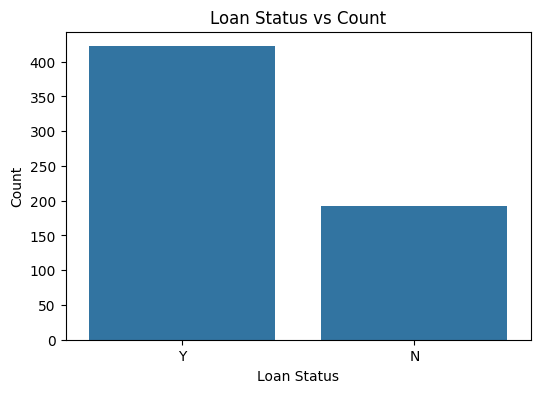

In [ ]:
# Data Visualization
# Visualize the target
plt.figure(figsize=(6, 4))
sb.countplot(x='Loan_Status', data=data)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Loan Status vs Count')
plt.show()

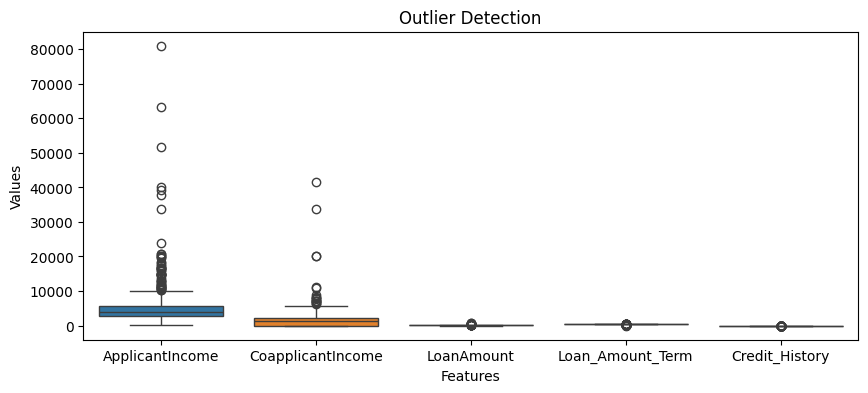

In [ ]:
# Detect Outliers in all input features using Visualization
plt.figure(figsize=(10, 4))
sb.boxplot(data=data.drop('Loan_ID', axis=1))
plt.xlabel('Features')
plt.ylabel('Values')
plt.title('Outlier Detection')
plt.show()

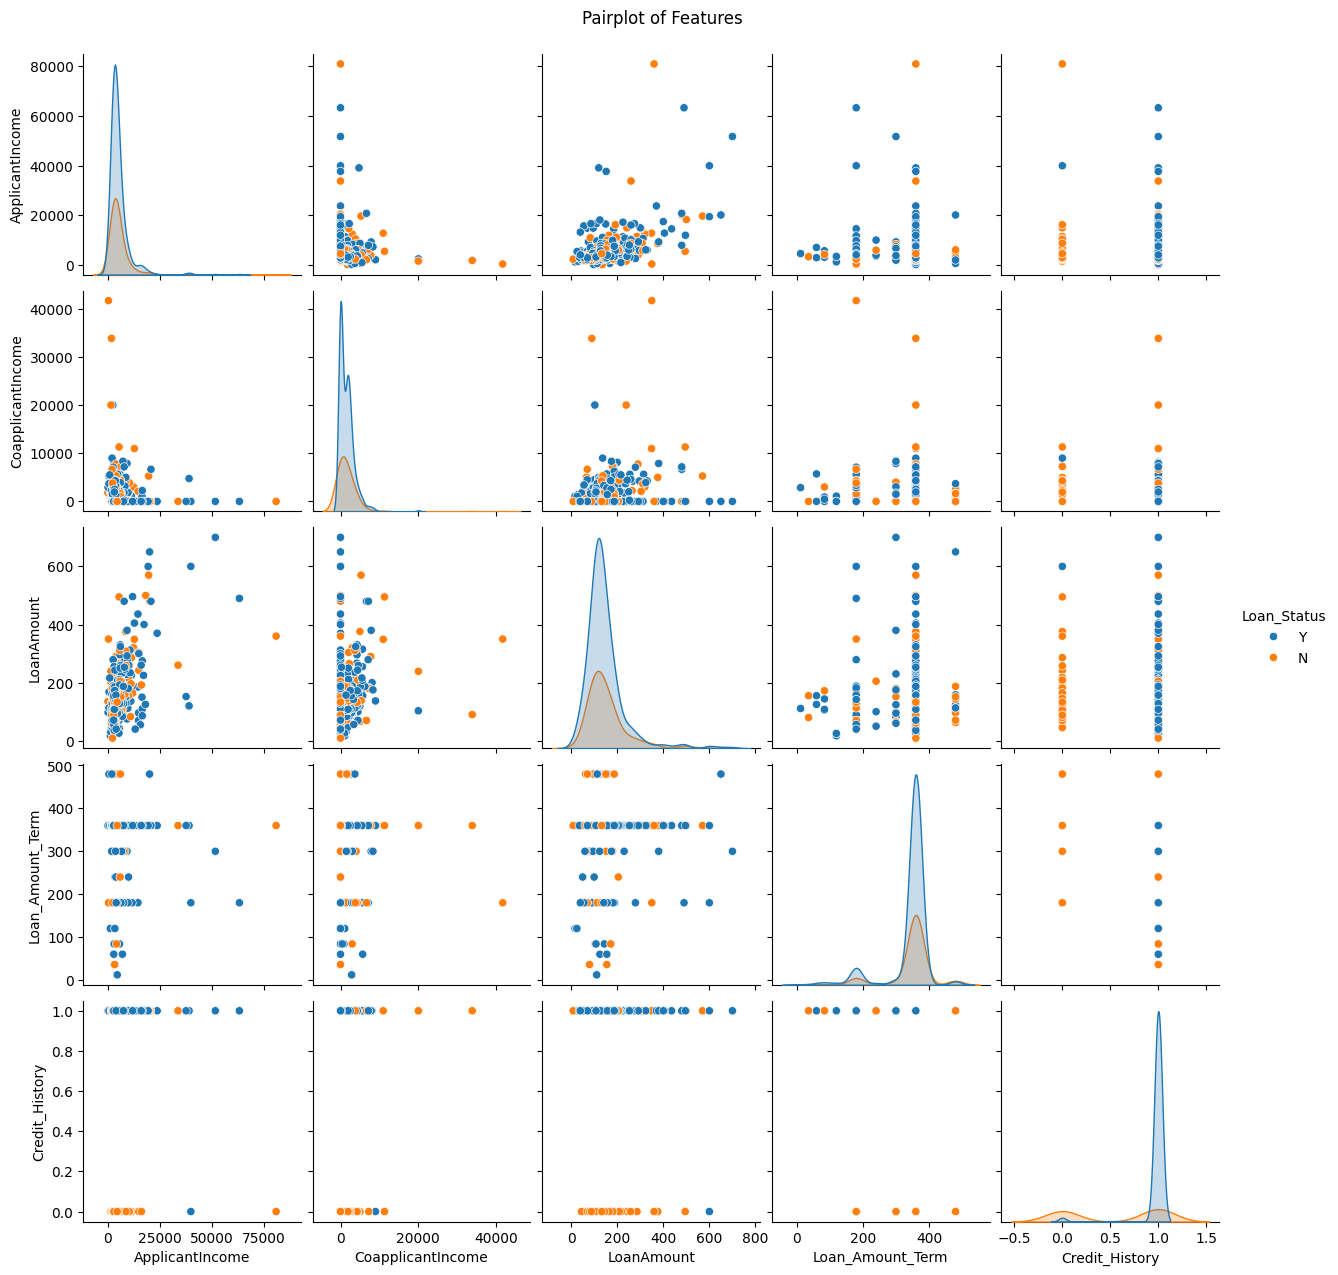

In [ ]:
# pairplot
sb.pairplot(data, hue='Loan_Status')
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

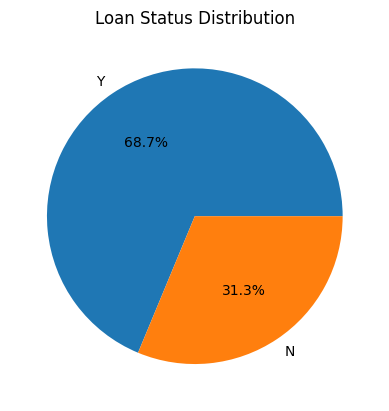

In [ ]:
# Pie chart for target
ln_st_count = data['Loan_Status'].value_counts() # value_counts() will count unique values of a column
# loan status count: ln_st_count
# Counts how many loan: Approved, Rejected
plt.pie(ln_st_count, labels=ln_st_count.index, autopct='%1.1f%%')
plt.title('Loan Status Distribution')
plt.show()

In [ ]:
# drop Loan_ID as it's not useful for prediction
data.drop('Loan_ID', axis=1, inplace=True)

# Handle all missing values just in one step:
for col in data :
  if data[col].dtype == 'object':
    data[col] = data[col].fillna(data[col].mode()[0])
  else :
    data[col] = data[col].fillna(data[col].median())


# convert Target 'Loan_Status' to binary (Y = 1, N = 0)
data["Loan_Status"] = data["Loan_Status"].map({"Y": 1, "N": 0})

# Handle categorical features using Label Encoding for simplicity
for col in data.select_dtypes(include="object").columns :
    data[col] = LabelEncoder().fit_transform(data[col])

'''
Label Encoding: convert categorical (text) data into numbers,
so that machine learning models can process them.
Why is this needed?
 - Machine learning models only understand numbers.
 - If you have text values like "Male" and "Female",
 you need to convert them into numeric values.

Selects all columns where the data type is object (i.e., text/categorical columns).
Converts the text categories into numeric labels for each column
'''


'\nLabel Encoding: convert categorical (text) data into numbers,\nso that machine learning models can process them.\nWhy is this needed?\n - Machine learning models only understand numbers.\n - If you have text values like "Male" and "Female",\n you need to convert them into numeric values.\n\nSelects all columns where the data type is object (i.e., text/categorical columns).\nConverts the text categories into numeric labels for each column\n'

In [ ]:
# Separate Features(X) and Target(y)

X = data.drop("Loan_Status", axis=1) # select all columns except 'Loan_Status' column
y = data["Loan_Status"] # select 'Loan_Status' column


In [ ]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,               # X = input features, y = target variable
    test_size=0.2,      # test size = 20%, training size = 80%
    random_state=42,    # random_state ensures reproducible results. (gives same data split every time).
    stratify=y          # keeps the same class proportions in train and test sets.
)

In [ ]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

'''
Consider the following example explaining fit_transform and transform:

for instance we have age and Sal columns.

fit:
mean of age
mean of Sal
SD of age
SD of Sal

feature mean  SD
age     37    10
Sal     65000 30000
------------------
transform
Xscaled = (x - mean) / SD

(40 - 37) / 10 = 0.3
(43000 - 65000) / 30000 = -0.73

'''

# What is Data Leakage ?
# Data leakage occurs when information from the test data is used during training.
# As a result, the model appears to perform very well during testing and evaluation,
# because it has already seen information from the test data,
# but it fails to perform well on new unseen data.

# To prevent our model from data leakage, we have done scaling after the train-test split.


'\nConsider the following example explaining fit_transform and transform:\n\nfor instance we have age and Sal columns.\n\nfit:\nmean of age\nmean of Sal\nSD of age\nSD of Sal\n\nfeature mean  SD\nage     37    10\nSal     65000 30000\n------------------\ntransform\nXscaled = (x - mean) / SD\n\n(40 - 37) / 10 = 0.3\n(43000 - 65000) / 30000 = -0.73\n\n'

In [ ]:
# Train Logistic Regression Model
model = LogisticRegression() # create object of Logistic Regression model

model.fit(X_train, y_train) # fit() method trains the model

'''
How Logistic Regression Works :

1. Learns the optimal weights (w₁, w₂, ..., wₙ) and bias (b) from the training data.
2. Calculates the weighted sum: w₁x₁ + w₂x₂ + ... + wₙxₙ + b.
3. Applies the sigmoid function to convert the result into a probability (0 to 1).
4. Uses a threshold (usually 0.5) to predict the class:
    Probability ≥ 0.5 → Class 1
    Probability < 0.5 → Class 0.
'''


'\nHow Logistic Regression Works :\n\n1. Learns the optimal weights (w₁, w₂, ..., wₙ) and bias (b) from the training data.\n2. Calculates the weighted sum: w₁x₁ + w₂x₂ + ... + wₙxₙ + b.\n3. Applies the sigmoid function to convert the result into a probability (0 to 1).\n4. Uses a threshold (usually 0.5) to predict the class:\n    Probability ≥ 0.5 → Class 1\n    Probability < 0.5 → Class 0.\n'

In [ ]:
# Make Predictions
y_pred = model.predict(X_test) # predict() method to test the model

In [ ]:
# Evaluate the model
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy: ", accuracy)
'''
Accuracy:
Accuracy focuses on, out of all the predictions made by the model,
how many were correctly predicted.

Accuracy = Correct Predictions / Total Predictions.

Accuracy = TP + TN / TP + TN + FP + FN​

Where:

TP = True Positives
TN = True Negatives
FP = False Positives
FN = False Negatives

'''

# precision
precision = precision_score(y_test, y_pred)
print("Model Precision: ", precision)

'''
Precision:
Precision: Of all predicted positives, how many were actually correct?

Precision focuses on, out of all the positive predictions made by the model,
how many were actually positive.

You should prioritize precision if:

1. A "False Alarm" causes an expensive or annoying problem.
2. The user's trust is easily broken by wrong predictions.
3. There is a punishment or heavy cost associated with being wrong.

Precision = TP / FP + TP​

'''

# recall:
recall = recall_score(y_test, y_pred)
print("Model Recall: ", recall)

'''
Recall:

Recall: Of all actual positives, how many did the model correctly find?

Recall focuses on, out of the total actual positive cases,
how many the model correctly predicted as positive,
even if some negative cases are incorrectly predicted as positive.

You should prioritize recall if:

1. A "Miss" is dangerous or life-threatening.
2. False Alarms are annoying but manageable.
3. The goal is completeness, not necessarily efficiency.

Recall = TP / TP + FN​
'''

# f1score: balanced measure of precision and recall
F1score = f1_score(y_test, y_pred)
print("Model F1score: ", F1score)

'''
F1-Score:
F1-Score measures the balance between Precision and Recall.

F1-Score tells us how well the model balances,
making correct positive predictions and finding actual positive cases.

F1-Score = 2 * (Precision * Recall) / (Precision + Recall)​

'''

# Confusion Matrix: shows the count of correct and incorrect predictions for each target class
confusionMatrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", confusionMatrix)

'''
# Understanding the Confusion Matrix (Through Human Confusion)

As human beings, we often face situations where we are uncertain and must choose between different options. For example:

* Should I say Yes or No?
* Is this right or wrong?
* Is this safe or unsafe?

When an AI model makes predictions, it also faces uncertainty. However, instead of expressing confusion, it organizes its decisions into clear categories by comparing its prediction with reality.

This comparison produces four possible outcomes:

* **True Positive (TP)** → AI predicted Positive, and it was actually Positive.
* **True Negative (TN)** → AI predicted Negative, and it was actually Negative.
* **False Positive (FP)** → AI predicted Positive, but it was actually Negative.
* **False Negative (FN)** → AI predicted Negative, but it was actually Positive.

### In Simple Words

* I correctly said **Yes** → True Positive
* I correctly said **No** → True Negative
* I wrongly said **Yes** → False Positive
* I wrongly said **No** → False Negative

This structured way of organizing correct and incorrect predictions is called a **Confusion Matrix**.

It helps us understand how well an AI model is performing by showing where it makes correct predictions and where it makes mistakes.

'''

# Classification Report: summary of classification metrics
classificationReport = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classificationReport)


Model Accuracy:  0.8617886178861789
Model Precision:  0.84
Model Recall:  0.9882352941176471
Model F1score:  0.9081081081081082

Confusion Matrix:
 [[22 16]
 [ 1 84]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



# Project Workflow:

1. Import Libraries

2. Download Dataset

3. Load Dataset

4. Understand Dataset

5. Data Preprocessing ( Removing Unnecessary Columns, Handling Missing Values
, Encoding Categorical Data )

6. Feature Selection

7. Train-Test Split

8. Feature Scaling (Part of Data Preprocessing)

9. Train Logistic Regression Model

10. Prediction

11. Model Evaluation



---




# Conclusion

The Loan Approval Prediction System improves decision making by quickly identifying eligible applicants.

This helps save processing time as well as reduce financial loss for banks.



---


